## Causal Structure Definitions

In [1]:
import sys
import os
import numpy as np
from pgmpy.estimators import BIC
from pgmpy.models import DiscreteBayesianNetwork
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from networkx.drawing.nx_agraph import graphviz_layout, to_agraph

np.random.seed(999)

sys.path.append(os.path.dirname(os.path.abspath(__name__)) + "/..")

## Chain Causal Structure (A → B → C)
def chain_discrete(N):
    A = np.random.randint(0, 5, N)
    B = (A + 1) % 5
    C = (B + 1) % 5
    return pd.DataFrame({'A': A, 'B': B, 'C': C})



def chain_discrete_noise(N, noise_level=0.1):
    """
    Generates a chain structure A → B → C with discrete values in {0,1,2,3,4},
    and adds noise to B and C with the specified noise_level.
    """
    A = np.random.randint(0, 5, N)
    
    # Add noise to B: with probability `noise_level`, replace (A + 1) % 5 with a random value
    B = (A + 1) % 5
    noise_mask_B = np.random.rand(N) < noise_level
    B[noise_mask_B] = np.random.randint(0, 5, size=noise_mask_B.sum())
    
    # Add noise to C: with probability `noise_level`, replace (B + 1) % 5 with a random value
    C = (B + 1) % 5
    noise_mask_C = np.random.rand(N) < noise_level
    C[noise_mask_C] = np.random.randint(0, 5, size=noise_mask_C.sum())
    
    return pd.DataFrame({'A': A, 'B': B, 'C': C})


# Fork Structure (A → B ← C)
def fork_discrete(N):
    A = np.random.randint(0, 3, N)
    C = np.random.randint(0, 3, N)
    B = (A + C)
    return pd.DataFrame({'A': A, 'B': B, 'C': C})

# Fork Structure (A → B ← C)
def fork_syn_discrete(N):
    A = np.random.randint(0, 3, N)
    C = np.random.randint(0, 3, N)
    B = (A ^ C)
    return pd.DataFrame({'A': A, 'B': B, 'C': C})

# Collider Structure (A → B → C and A → C)
def collider_discrete(N):
    A = np.random.randint(0, 3, N)
    B = (A + 1) % 3
    C = (A + B) % 3
    return pd.DataFrame({'A': A, 'B': B, 'C': C})

## Chain Causal Structure (A → B → C) + D
def chain_discrete_d(N):
    A = np.random.randint(0, 5, N)
    B = (A + 1) % 5
    C = (B + 1) % 5
    D = np.random.randint(0, 3, N)
    return pd.DataFrame({'A': A, 'B': B, 'C': C, 'D': D})

# USE FOR THRESHOLD
# Fork Structure (A → B ← C) + D
def fork_discrete_d(N):
    A = np.random.randint(0, 3, N)
    C = np.random.randint(0, 3, N)
    B = (A + C)
    D = np.random.randint(0, 3, N)
    return pd.DataFrame({'A': A, 'B': B, 'C': C, 'D': D})

# Fork Structure (A → B ← C) + D
def fork_syn_discrete_d(N):
    A = np.random.randint(0, 3, N)
    C = np.random.randint(0, 3, N)
    B = (A ^ C)
    D = np.random.randint(0, 3, N)
    return pd.DataFrame({'A': A, 'B': B, 'C': C, 'D': D})

# Collider Structure (A → B → C and A → C) + D
def collider_discrete_d(N):
    A = np.random.randint(0, 3, N)
    B = (A + 1) % 3
    C = (A + B) % 3
    D = np.random.randint(0, 3, N)
    return pd.DataFrame({'A': A, 'B': B, 'C': C, 'D': D})

# Model 3: Discrete Causal Chain with Two Synergistic Mechanisms
def large_discrete(n_samples=100_000):

    X1 = (np.random.binomial(1, 0.5, n_samples)  + np.random.binomial(1, 0.1, n_samples)) % 2 # Add noise

    X2 = (np.random.binomial(1, 0.5, n_samples) + np.random.binomial(1, 0.1, n_samples)) % 2  # Add noise

    X3 = X1 ^ X2 + np.random.binomial(1, 0.1, n_samples)  # Add noise

    X4 = np.random.binomial(1, 0.1, n_samples)

    X5 = (X4 + X3 + np.random.binomial(1, 0.1, n_samples)) % 2 # Add noise

    X6 = X4*X3 + np.random.binomial(1, 0.1, n_samples)  # Add noise

    X7 = (X1 + X4 + np.random.binomial(1, 0.1, n_samples)) % 2  # Add noise

    X8 = np.random.binomial(1, 0.5, n_samples) 

    X9 =  np.random.binomial(1, 0.5, n_samples)

    return pd.DataFrame({'X1': X1, 'X2': X2, 'X3': X3, 'X4': X4, 'X5': X5, 'X6': X6, 'X7': X7, 'X8': X8, 'X9': X9})


def visualize_model(model, title):
    pos = graphviz_layout(model, prog="dot")
    plt.figure(figsize=(6, 4))
    nx.draw(model, pos, with_labels=True, node_size=3000, node_color="skyblue", 
            edge_color="gray", font_size=14, font_weight='bold')
    plt.title(title)
    plt.show()

## Discrete Chain (Markov-Equivalent )

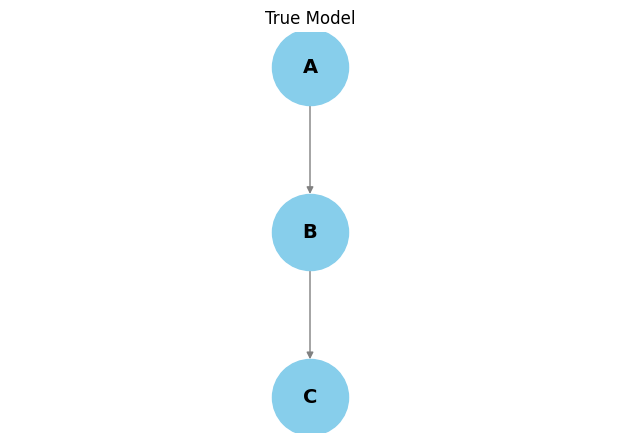

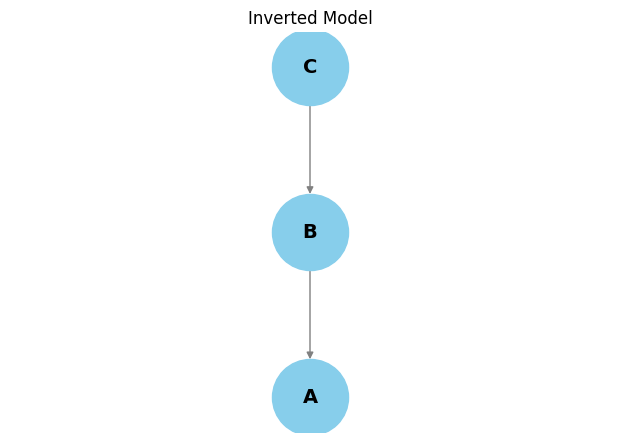

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'A': 'N', 'B': 'N', 'C': 'N'}


True Model BIC:  -1760.3612193737993
Inverted Model BIC:  -1760.3612193737988


In [2]:
# Chain Discrete
chain_data = chain_discrete(1000)
true_model = DiscreteBayesianNetwork([
    ('A', 'B'),
    ('B', 'C'),
])

inverted_model = DiscreteBayesianNetwork([
    ('C', 'B'),
    ('B', 'A'),
])

visualize_model(true_model, "True Model")
visualize_model(inverted_model, "Inverted Model")

scoring_method = BIC(chain_data)
print("True Model BIC: ", scoring_method.score(true_model))
print("Inverted Model BIC: ", scoring_method.score(inverted_model))


### Additive Noise Model

In [3]:
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split


def fit_anm_and_test_independence(X, Y):
    """Fit Y = f(X) + noise and test independence of residuals"""
    X_train, X_test, Y_train, Y_test = train_test_split(X.reshape(-1, 1), Y, test_size=0.3)
    model = GradientBoostingRegressor().fit(X_train, Y_train)
    preds = model.predict(X_test)
    residuals = Y_test - preds
    corr, _ = pearsonr(residuals, X_test.flatten())
    return abs(corr)


In [4]:
def monte_carlo_anm_direction_test(a, b, n_trials=100):
    """
    Run ANM-based causal direction test n_trials times with resampling.
    
    Parameters:
        a, b: numpy arrays (same length)
        n_trials: number of Monte Carlo runs (default = 100)

    Returns:
        Dict with counts and proportions of inferred directions.
    """
    a = np.array(a)
    b = np.array(b)
    assert len(a) == len(b), "Inputs a and b must be of the same length"
    
    count_a_to_b = 0
    count_b_to_a = 0
    N = len(a)

    for _ in range(n_trials):
        # idx = np.random.choice(N, N, replace=True)
        # a_sample = a[idx]
        # b_sample = b[idx]

        corr_a_to_b = fit_anm_and_test_independence(a, b)
        corr_b_to_a = fit_anm_and_test_independence(b, a)

        if corr_a_to_b < corr_b_to_a:
            count_a_to_b += 1
        else:
            count_b_to_a += 1

    return {
        "a_to_b_count": count_a_to_b,
        "b_to_a_count": count_b_to_a,
        "a_to_b_ratio": count_a_to_b / n_trials,
        "b_to_a_ratio": count_b_to_a / n_trials,
    }


result = monte_carlo_anm_direction_test(chain_data["A"], chain_data["B"], n_trials=100)
print(result)

{'a_to_b_count': 49, 'b_to_a_count': 51, 'a_to_b_ratio': 0.49, 'b_to_a_ratio': 0.51}


### Noise Chain Discrete

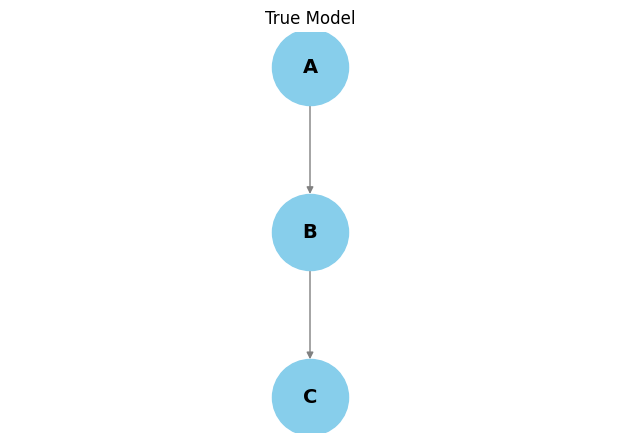

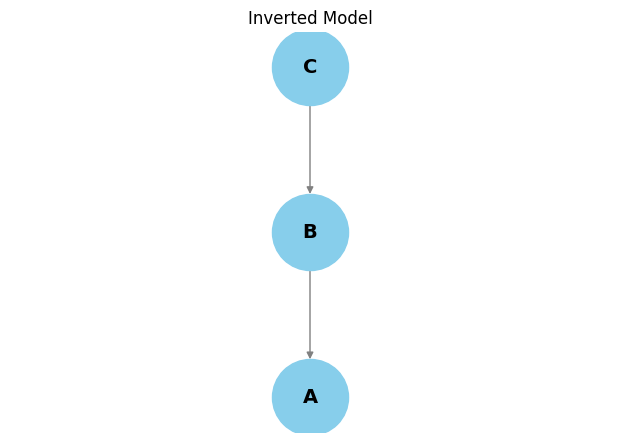

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'A': 'N', 'B': 'N', 'C': 'N'}


True Model BIC:  -37740.706209258045
Inverted Model BIC:  -37740.70620925805


In [5]:
# Chain Discrete
chain_data = chain_discrete_noise(10000, noise_level=0.4)
true_model = DiscreteBayesianNetwork([
    ('A', 'B'),
    ('B', 'C'),
])

inverted_model = DiscreteBayesianNetwork([
    ('C', 'B'),
    ('B', 'A'),
])

visualize_model(true_model, "True Model")
visualize_model(inverted_model, "Inverted Model")

scoring_method = BIC(chain_data)
print("True Model BIC: ", scoring_method.score(true_model))
print("Inverted Model BIC: ", scoring_method.score(inverted_model))


In [6]:
result = monte_carlo_anm_direction_test(chain_data["A"], chain_data["B"], n_trials=100)
print(result)

{'a_to_b_count': 51, 'b_to_a_count': 49, 'a_to_b_ratio': 0.51, 'b_to_a_ratio': 0.49}


### Noise added differently

In [7]:
import numpy as np
import pandas as pd
from pgmpy.estimators import BIC
from pgmpy.models import BayesianNetwork
from pgmpy.estimators import BayesianEstimator

# Step 1: Generate chain data with noise
def chain_discrete_noise(N, noise_level=0.4):
    A = np.random.randint(0, 5, N)
    B = (A + 1 + np.random.choice([0, 1, -1], size=N, p=[1-noise_level, noise_level/2, noise_level/2])) % 5
    C = (B + 1 + np.random.choice([0, 1, -1], size=N, p=[1-noise_level, noise_level/2, noise_level/2])) % 5
    return pd.DataFrame({'A': A, 'B': B, 'C': C})

# Step 2: Load data
chain_data = chain_discrete_noise(10000, noise_level=0.4)

# Step 3: Define true and inverted models
true_model = DiscreteBayesianNetwork([('A', 'B'), ('B', 'C')])
inverted_model = DiscreteBayesianNetwork([('C', 'B'), ('B', 'A')])

# Step 4: Fit models (required before scoring!)
true_model.fit(chain_data, estimator=BayesianEstimator)
inverted_model.fit(chain_data, estimator=BayesianEstimator)


scoring_method = BIC(chain_data)
print("True Model BIC: ", scoring_method.score(true_model))
print("Inverted Model BIC: ", scoring_method.score(inverted_model))

# # Step 5: Score using BIC
# scoring_method = 
# print("True Model BIC: ", scoring_method.score(true_model))
# print("Inverted Model BIC: ", scoring_method.score(inverted_model))


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'A': 'N', 'B': 'N', 'C': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'A': 'N', 'B': 'N', 'C': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'A': 'N', 'B': 'N', 'C': 'N'}


True Model BIC:  -35268.63789228085
Inverted Model BIC:  -35268.63789228085


### HSIC (Hilbert-Schmidt Independence Criterion)

python implementation of Hilbert Schmidt Independence Criterion
hsic_gam implements the HSIC test using a Gamma approximation
Adapted to Python 3.12

Gretton, A., Fukumizu, K., Teo, C. H., Song, L., Scholkopf, B., 
& Smola, A. J. (2007). A kernel statistical test of independence. 
In Advances in neural information processing systems (pp. 585-592).

In [12]:
"""
Hilbert Schmidt Information Criterion with a Gaussian kernel, based on the
following references
[1]: https://link.springer.com/chapter/10.1007/11564089_7
[2]: https://www.researchgate.net/publication/301818817_Kernel-based_Tests_for_Joint_Independence

"""
import numpy

def centering(M):
    """
    Calculate the centering matrix
    """
    n = M.shape[0]
    unit = numpy.ones([n, n])
    identity = numpy.eye(n)
    H = identity - unit/n

    return numpy.matmul(M, H)

def gaussian_grammat(x, sigma=None):
    """
    Calculate the Gram matrix of x using a Gaussian kernel.
    If the bandwidth sigma is None, it is estimated using the median heuristic:
    ||x_i - x_j||**2 = 2 sigma**2
    """
    try:
        x.shape[1]
    except IndexError:
        x = x.reshape(x.shape[0], 1)

    xxT = numpy.matmul(x, x.T)
    xnorm = numpy.diag(xxT) - xxT + (numpy.diag(xxT) - xxT).T
    if sigma is None:
        mdist = numpy.median(xnorm[xnorm!= 0])
        sigma = numpy.sqrt(mdist*0.5)


   # --- If bandwidth is 0, add machine epsilon to it
    if sigma==0:
        eps = 7./3 - 4./3 - 1
        sigma += eps

    KX = - 0.5 * xnorm / sigma / sigma
    numpy.exp(KX, KX)
    return KX

def dHSIC_calc(K_list):
    """
    Calculate the HSIC estimator in the general case d > 2, as in
    [2] Definition 2.6
    """
    if not isinstance(K_list, list):
        K_list = list(K_list)

    n_k = len(K_list)

    length = K_list[0].shape[0]
    term1 = 1.0
    term2 = 1.0
    term3 = 2.0/length

    for j in range(0, n_k):
        K_j = K_list[j]
        term1 = numpy.multiply(term1, K_j)
        term2 = 1.0/length/length*term2*numpy.sum(K_j)
        term3 = 1.0/length*term3*K_j.sum(axis=0)

    term1 = numpy.sum(term1)
    term3 = numpy.sum(term3)
    dHSIC = (1.0/length)**2*term1+term2-term3
    return dHSIC

def HSIC(x, y):
    """
    Calculate the HSIC estimator for d=2, as in [1] eq (9)
    """
    n = x.shape[0]
    return numpy.trace(numpy.matmul(centering(gaussian_grammat(x)),centering(gaussian_grammat(y))))/n/n

def dHSIC(*argv):
    assert len(argv) > 1, "dHSIC requires at least two arguments"

    if len(argv) == 2:
        x, y = argv
        return HSIC(x, y)

    K_list = [gaussian_grammat(_arg) for _arg in argv]

    return dHSIC_calc(K_list)


dHSIC(chain_data["A"].values, chain_data["B"].values)

0.03386937192035245

In [13]:
dHSIC(chain_data["B"].values, chain_data["A"].values)

0.033869371920352456

### Test LinGam Model for discrete chain (Markov-Equivalent) data.

Estimated causal order: ['C', 'B', 'A']

Estimated adjacency matrix:
      A    B         C
A  0.0  0.0 -0.189601
B  0.0  0.0  0.000000
C  0.0  0.0  0.000000


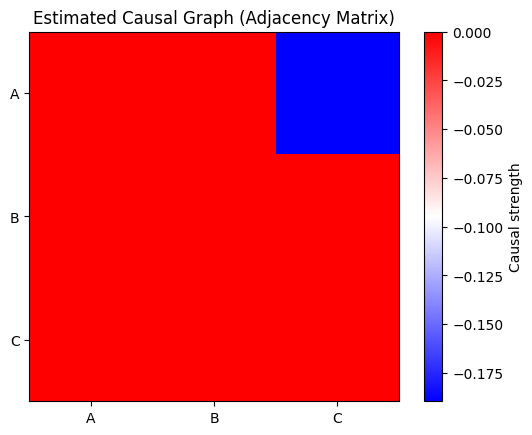

In [ ]:
from lingam import DirectLiNGAM

model = DirectLiNGAM()
model.fit(chain_data)
ordering = model.causal_order_
print("Estimated causal order:", [chain_data.columns[i] for i in ordering])

# Adjacency matrix (causal graph structure)
adj_matrix = model.adjacency_matrix_
print("\nEstimated adjacency matrix:\n", pd.DataFrame(adj_matrix, columns=chain_data.columns, index=chain_data.columns))

# Optional: visualize the graph using a heatmap
plt.imshow(adj_matrix, cmap="bwr", interpolation="none")
plt.colorbar(label="Causal strength")
plt.xticks(range(len(chain_data.columns)), chain_data.columns)
plt.yticks(range(len(chain_data.columns)), chain_data.columns)
plt.title("Estimated Causal Graph (Adjacency Matrix)")
plt.show()

### Try other scoring methods

In [ ]:
from pgmpy.estimators import *
def get_scoring_methods(data):
    scoring_methods = [
    K2(data),
    BDeu(data),
    BIC(data),
    AIC(data),
    LogLikelihoodGauss(data),
    BICGauss(data)]

    return scoring_methods

scoring_methods = get_scoring_methods(chain_data)
for scoring_method in scoring_methods:
    print("Scoring Method:", scoring_method.__class__.__name__)
    print("True Model Score:", scoring_method.score(true_model))
    # print("Estimated Model Score:", scoring_method.score())
    print("Inverted Model Score:", scoring_method.score(inverted_model))


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'A': 'N', 'B': 'N', 'C': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'A': 'N', 'B': 'N', 'C': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'A': 'N', 'B': 'N', 'C': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'A': 'N', 'B': 'N', 'C': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'A': 'N', 'B': 'N', 'C': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'A': 'N', 'B': 'N', 'C': 'N'}


Scoring Method: K2
True Model Score: -1799.9938017250302
Inverted Model Score: -1799.9938017250302
Scoring Method: BDeu
True Model Score: -1710.6040620739232
Inverted Model Score: -1710.6040620739213
Scoring Method: BIC
True Model Score: -1760.3612193737993
Inverted Model Score: -1760.3612193737988
Scoring Method: AIC
True Model Score: -1652.3906032361924
Inverted Model Score: -1652.390603236192
Scoring Method: LogLikelihoodGauss
True Model Score: -5285.852355543882
Inverted Model Score: -5285.8523555438815
Scoring Method: BICGauss
True Model Score: -5313.48337665981
Inverted Model Score: -5313.48337665981


Python implementation of Information Geometry Causal Inference
Python 2.7.12

P. Daniusis, D. Janzing, J. Mooij, J. Zscheischler, B. Steudel,
K. Zhang, B. Scholkopf:  Inferring deterministic causal relations.
Proceedings of the 26th Annual Conference on Uncertainty in Artificial 
Intelligence (UAI-2010).  
http://event.cwi.nl/uai2010/papers/UAI2010_0121.pdf

Implementation has been changed to match Python 3.12

In [ ]:
import numpy as np
from scipy.special import psi

def igci(x, y, refMeasure=1, estimator=2):
    xi = np.real(x).reshape(-1, 1)
    yi = np.real(y).reshape(-1, 1)

    Lx, dimx = xi.shape
    Ly, dimy = yi.shape

    # ----- input data check -----
    if dimx != 1:
        print('Dimensionality of x must be 1')
        return None

    if Lx < 20:
        print('Not enough observations in x (must be > 20)')
        return None

    if dimy != 1:
        print('Dimensionality of y must be 1')
        return None

    if Ly < 20:
        print('Not enough observations in y (must be > 20)')
        return None

    if Lx != Ly:
        print('Lengths of x and y must be equal')
        return None
    # ----- -----

    if refMeasure == 1:
        xi = (xi - np.min(xi)) / (np.max(xi) - np.min(xi))
        yi = (yi - np.min(yi)) / (np.max(yi) - np.min(yi))
    elif refMeasure == 2:
        xi = (xi - np.mean(xi)) / np.std(xi)
        yi = (yi - np.mean(yi)) / np.std(yi)
    else:
        print('Warning: unknown reference measure - no scaling applied')
        return None

    if estimator == 1:
        x1 = np.sort(xi, axis=0)
        y1 = np.sort(yi, axis=0)

        n1 = x1.shape[0]
        hx = 0.0
        for i in range(n1 - 1):
            delta = x1[i + 1, 0] - x1[i, 0]
            if delta != 0:
                hx += np.log(np.abs(delta))

        hx = hx / (n1 - 1) + psi(n1) - psi(1)

        n2 = y1.shape[0]
        hy = 0.0
        for i in range(n2 - 1):
            delta = y1[i + 1, 0] - y1[i, 0]
            if delta != 0:
                hy += np.log(np.abs(delta))

        hy = hy / (n2 - 1) + psi(n2) - psi(1)

        f = hy - hx
        return f

    elif estimator == 2:
        a = 0.0
        b = 0.0

        ind1 = np.argsort(xi[:, 0])
        ind2 = np.argsort(yi[:, 0])

        for i in range(Lx - 1):
            X1 = xi[ind1[i], 0]
            X2 = xi[ind1[i + 1], 0]
            Y1 = yi[ind1[i], 0]
            Y2 = yi[ind1[i + 1], 0]
            if X1 != X2 and Y1 != Y2:
                a += np.log(np.abs((Y2 - Y1) / (X2 - X1)))

            X1 = xi[ind2[i], 0]
            X2 = xi[ind2[i + 1], 0]
            Y1 = yi[ind2[i], 0]
            Y2 = yi[ind2[i + 1], 0]
            if X1 != X2 and Y1 != Y2:
                b += np.log(np.abs((X2 - X1) / (Y2 - Y1)))

        f = (a - b) / Lx
        return f

    else:
        print('Unknown estimator')
        return None

print("""    Outputs: 
    f < 0:		the method prefers the causal direction x -> y
    f > 0:		the method prefers the causal direction y -> x
""")

    Outputs: 
    f < 0:		the method prefers the causal direction x -> y
    f > 0:		the method prefers the causal direction y -> x



In [ ]:
f = igci(chain_data["A"], chain_data["B"], refMeasure=2, estimator=2)
f

-0.00010534808564395148

In [ ]:
f = igci(chain_data["B"], chain_data["C"], refMeasure=2, estimator=2)
f

-0.0001554031394680988

IGCI suggest correct causal direction for discrete chain (Markov-Equivalent) data. 

A -> B -> C

## Fork-Discrete Chain 

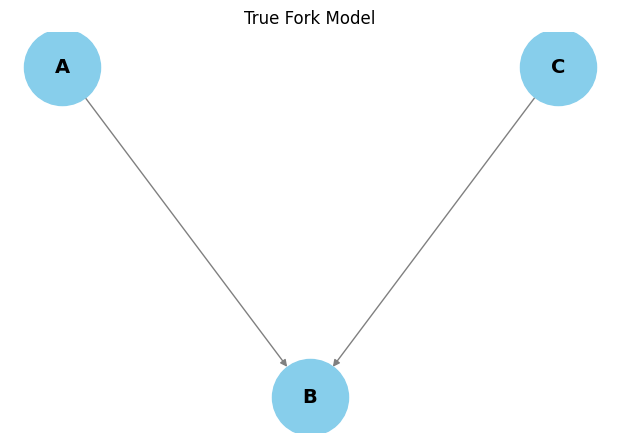

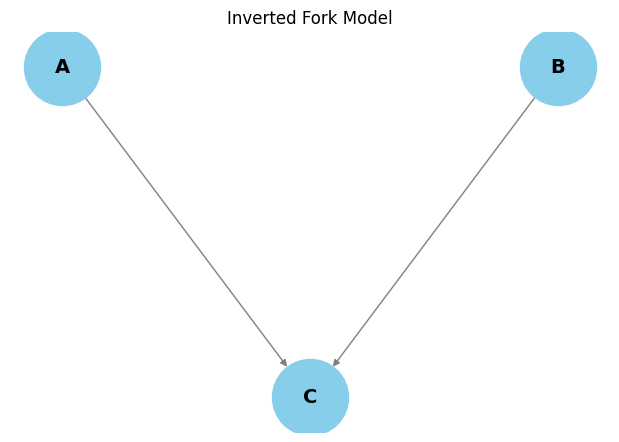

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'A': 'N', 'B': 'N', 'C': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'A': 'N', 'B': 'N', 'C': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'A': 'N', 'B': 'N', 'C': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'A': 'N', 'B': 'N', 'C': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'A': 'N', 'B': 'N', 'C': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'A': 'N', 'B': 'N', 'C': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'A': 'N', 'B': 'N', 'C': 'N'}
/home/kaleem/miniconda3/envs/thesis/lib/python3.

True Fork Model BIC:  -22154.011656415198
Inverted Fork Model BIC:  -26384.1256635357
Scoring Method: K2
True Model Score: -22210.387740085658
Inverted Model Score: -28825.344718203043
Scoring Method: BDeu
True Model Score: -22053.06193936951
Inverted Model Score: -28803.33651600219
Scoring Method: BIC
True Model Score: -22154.011656415198
Inverted Model Score: -28809.43035916559
Scoring Method: AIC
True Model Score: -22009.804848975673
Inverted Model Score: -28722.90627470188
Scoring Method: LogLikelihoodGauss


/home/kaleem/miniconda3/envs/thesis/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)


True Model Score: 289412.5946722286
Inverted Model Score: -32971.99990438589
Scoring Method: BICGauss
True Model Score: 289375.75331074075
Inverted Model Score: -33008.841265873794


/home/kaleem/miniconda3/envs/thesis/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/kaleem/miniconda3/envs/thesis/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/kaleem/miniconda3/envs/thesis/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)


In [ ]:
fork_data = fork_discrete(10000)
true_model =DiscreteBayesianNetwork([
    ('A', 'B'),
    ('C', 'B'),
])

inverted_fork = DiscreteBayesianNetwork([
    ('A', 'C'),
    ('B', 'C'),
])
visualize_model(true_model, "True Fork Model")
visualize_model(inverted_fork, "Inverted Fork Model")

score = BIC(fork_data)

print("True Fork Model BIC: ", score.score(true_model))
print("Inverted Fork Model BIC: ", score.score(inverted_fork))

scoring_methods = get_scoring_methods(fork_data)
for scoring_method in scoring_methods:
    print("Scoring Method:", scoring_method.__class__.__name__)
    print("True Model Score:", scoring_method.score(true_model))
    # print("Estimated Model Score:", scoring_method.score())
    print("Inverted Model Score:", scoring_method.score(inverted_model))




LogLikelihoodGauss and BICGauss give the correct causal direction for fork-discrete chain data, need more testing to be sure.

## Collider-Discrete 

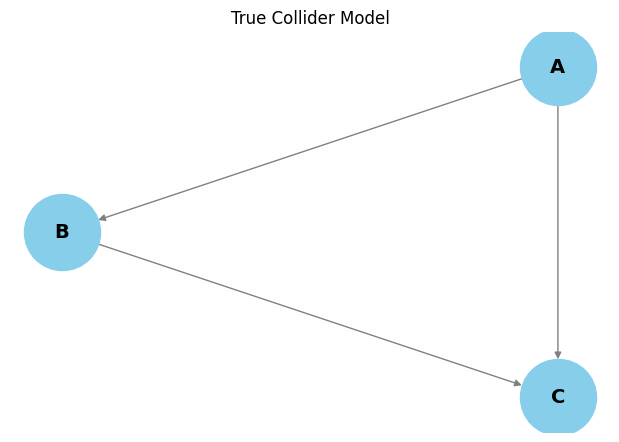

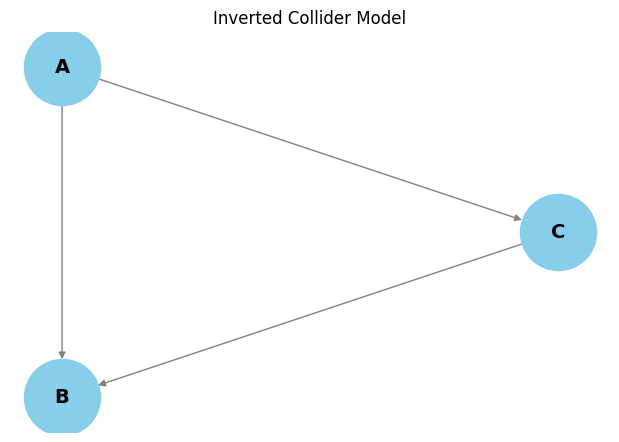

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'A': 'N', 'B': 'N', 'C': 'N'}


True Collider Model BIC:  -11105.816425176567
Inverted Collider Model BIC:  -11105.816425176567


In [ ]:
collider_discrete_data = collider_discrete(10000)
model =DiscreteBayesianNetwork([
    ('A', 'B'),
    ('B', 'C'),
    ('A', 'C'),
])

inverted_collider = DiscreteBayesianNetwork([
    ('A', 'B'),
    ('C', 'B'),
    ('A', 'C'),
])
visualize_model(model, "True Collider Model")
visualize_model(inverted_collider, "Inverted Collider Model")
score = BIC(collider_discrete_data)
print("True Collider Model BIC: ", score.score(model))
print("Inverted Collider Model BIC: ", score.score(inverted_collider))

In [ ]:
scoring_methods = get_scoring_methods(collider_discrete_data)

for scoring_method in scoring_methods:
    print("Scoring Method:", scoring_method.__class__.__name__)
    print("True Model Score:", scoring_method.score(model))
    # print("Estimated Model Score:", scoring_method.score())
    print("Inverted Model Score:", scoring_method.score(inverted_model))

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'A': 'N', 'B': 'N', 'C': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'A': 'N', 'B': 'N', 'C': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'A': 'N', 'B': 'N', 'C': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'A': 'N', 'B': 'N', 'C': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'A': 'N', 'B': 'N', 'C': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'A': 'N', 'B': 'N', 'C': 'N'}


Scoring Method: K2
True Model Score: -11083.437794817793
Inverted Model Score: -11087.596677901138
Scoring Method: BDeu
True Model Score: -11064.727361796058
Inverted Model Score: -11094.7626936144
Scoring Method: BIC
True Model Score: -11105.816425176567
Inverted Model Score: -11050.55438294471
Scoring Method: AIC
True Model Score: -11012.082000340877
Inverted Model Score: -11000.082000340877
Scoring Method: LogLikelihoodGauss


/home/kaleem/miniconda3/envs/thesis/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/kaleem/miniconda3/envs/thesis/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/kaleem/miniconda3/envs/thesis/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)


True Model Score: 281574.8776910932


/home/kaleem/miniconda3/envs/thesis/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/kaleem/miniconda3/envs/thesis/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/kaleem/miniconda3/envs/thesis/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)


Inverted Model Score: 298339.5917396079
Scoring Method: BICGauss
True Model Score: 281533.4311594193
Inverted Model Score: 298302.75037812


/home/kaleem/miniconda3/envs/thesis/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/kaleem/miniconda3/envs/thesis/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/kaleem/miniconda3/envs/thesis/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/kaleem/miniconda3/envs/thesis/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or predictio

## Large Discrete

In [ ]:
from algorithms.dag_ii import dag_ii

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'X1': 'N', 'X2': 'N', 'X3': 'N', 'X4': 'N', 'X5': 'N', 'X6': 'N', 'X7': 'N', 'X8': 'N', 'X9': 'N'}


[{'triplet': ('X1', 'X2', 'X3'), 'InteractionInfo': -0.7469489416344928}, {'triplet': ('X1', 'X2', 'X4'), 'InteractionInfo': -0.00018951311053116981}, {'triplet': ('X1', 'X2', 'X5'), 'InteractionInfo': -0.48103776170771706}, {'triplet': ('X1', 'X2', 'X6'), 'InteractionInfo': -0.016366068940457}, {'triplet': ('X1', 'X2', 'X7'), 'InteractionInfo': -0.0002650998192437193}, {'triplet': ('X1', 'X2', 'X8'), 'InteractionInfo': -0.0002259970459417282}, {'triplet': ('X1', 'X2', 'X9'), 'InteractionInfo': -0.000662298236241643}, {'triplet': ('X1', 'X3', 'X4'), 'InteractionInfo': -0.00039253794383053986}, {'triplet': ('X1', 'X3', 'X5'), 'InteractionInfo': 0.1221363139948699}, {'triplet': ('X1', 'X3', 'X6'), 'InteractionInfo': 0.009050965868885097}, {'triplet': ('X1', 'X3', 'X7'), 'InteractionInfo': 0.0918591656384482}, {'triplet': ('X1', 'X3', 'X8'), 'InteractionInfo': -5.4395626548409126e-05}, {'triplet': ('X1', 'X3', 'X9'), 'InteractionInfo': -0.00013301146141664333}, {'triplet': ('X1', 'X4', 'X

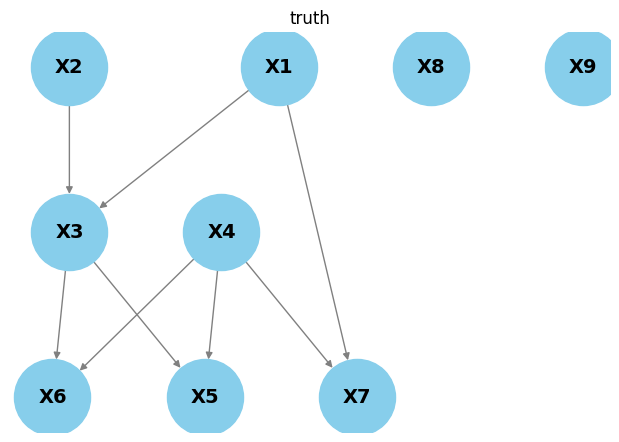

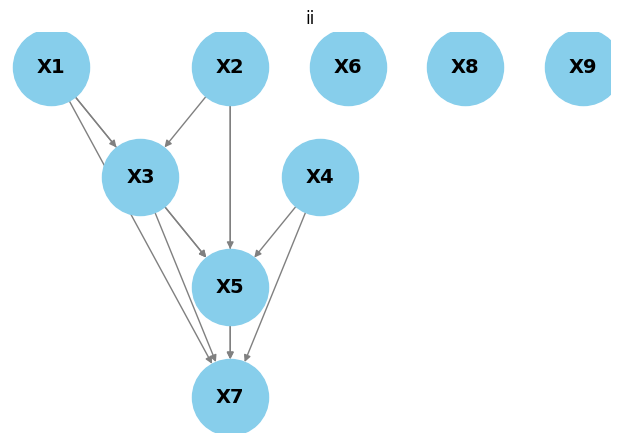

In [ ]:
large_discrete_data = large_discrete(10000)
model =DiscreteBayesianNetwork([
    ("X1", "X3"),
    ("X2", "X3"),
    ("X4", "X5"),
    ("X3", "X5"),
    ("X4", "X6"),
    ("X3", "X6"),
    ("X1", "X7"),
    ("X4", "X7"),
])

# triplets=[("X1","X2","X3"),("X3","X4","X5"),("X3","X4","X6"),("X1","X4","X7")]

model.add_node("X8")
model.add_node("X9")

score = BIC(large_discrete_data)

ii = dag_ii(large_discrete_data)


visualize_model(model, "truth")
visualize_model(ii, "ii")


In [ ]:
score = BIC(large_discrete_data)

print(f"True model score (BIC): {score.score(model)}")
print(f"II model score (BIC): {score.score(ii)}")

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'X1': 'N', 'X2': 'N', 'X3': 'N', 'X4': 'N', 'X5': 'N', 'X6': 'N', 'X7': 'N', 'X8': 'N', 'X9': 'N'}


True model score (BIC): -47837.266493590534
II model score (BIC): -58638.943658986616


# Models with error

In [ ]:
import numpy as np
import pandas as pd

def chain_discrete_with_error(N, error_prob=0.1):
    A = np.random.randint(0, 5, N)
    B = (A + 1) % 5
    C = (B + 1) % 5

    # Add noise to B
    mask_B = np.random.rand(N) < error_prob
    B[mask_B] = np.random.randint(0, 5, np.sum(mask_B))

    # Add noise to C
    mask_C = np.random.rand(N) < error_prob
    C[mask_C] = np.random.randint(0, 5, np.sum(mask_C))

    return pd.DataFrame({'A': A, 'B': B, 'C': C})


In [ ]:
chain_data_with_error = chain_discrete_with_error(1000, error_prob=0.1)
true_model = DiscreteBayesianNetwork([
    ('A', 'B'),
    ('B', 'C'),
])
inverted_model = DiscreteBayesianNetwork([
    ('C', 'B'),
    ('B', 'A'),
])

score = BIC(chain_data_with_error)
print("True Model BIC: ", score.score(true_model))
print("Inverted Model BIC: ", score.score(inverted_model))

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'A': 'N', 'B': 'N', 'C': 'N'}


True Model BIC:  -2746.5903460839822
Inverted Model BIC:  -2746.590346083982
